# Data Preparation and Feature Engineering

Welcome to Module 2: Machine Learning. In this module we teach a computer to make predictions from data. All three notebooks in this module tell one story: **predicting who survived the Titanic disaster**. This first notebook covers everything that happens *between* raw data and a model-ready dataset. That may sound like boring plumbing, but it is where most of the real work (and most of the mistakes) in machine learning happen.

**What you will learn**

- What machine learning is, and what "features" and "target" mean
- Why you must split your data into train and test sets *before* anything else
- How to fill in missing values the machine learning way (`SimpleImputer`)
- How to turn text categories into numbers (`OneHotEncoder`, `OrdinalEncoder`)
- How to put numbers on comparable scales (`StandardScaler`, `MinMaxScaler`)
- How to invent new, better columns from the ones you have (feature engineering)
- How to wire every step into one leak-proof object (`Pipeline` + `ColumnTransformer`)

## How to run this notebook

You can run this notebook in two ways:

- **Locally with Jupyter**: open it in Jupyter Notebook, JupyterLab, or VS Code and run the cells from top to bottom.
- **On Google Colab**: upload the notebook (or open it straight from GitHub) and run the cells from top to bottom.

The setup cell below installs any missing packages automatically, so it works in both places. You do not need any account, API key, or paid service. The dataset is loaded from a public URL, so you only need an internet connection.

In [1]:
# SETUP - run this cell first. It installs any missing packages.
# On Google Colab most packages are already installed, so this usually does nothing.
import importlib.util, subprocess, sys

def ensure(package, pip_name=None):
    if importlib.util.find_spec(package) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or package])

ensure("pandas"); ensure("numpy"); ensure("sklearn", "scikit-learn"); ensure("matplotlib")

## 1. From analytics to machine learning

In Module 1 you *described* data: you computed averages, made charts, and answered questions about the past. **Machine learning (ML)** goes one step further: we show a computer many past examples, it finds patterns in them, and then it uses those patterns to make predictions about *new* examples it has never seen.

The kind of ML we do in this module is called **supervised learning**: learning from examples where the correct answer is already known.

- **Features (X)**: the input columns the model is allowed to look at. For a passenger: age, ticket class, sex, fare paid, and so on.
- **Target (y)**: the column we want to predict. For us: did the passenger survive (1) or not (0)?

The model's job is to learn the relationship between X and y from past examples, so it can predict y for new rows where we only have X.

### Why data preparation matters

A machine learning model is, at its core, a lot of math. Math has three demands that raw data almost never meets:

| Models need... | Raw data often has... | Our fix |
|---|---|---|
| Numbers only | Text like `"male"` / `"female"` | Encoding (Section 5) |
| No gaps | Missing values (empty cells) | Imputation (Section 4) |
| Sensible scales | Age 0-80 next to Fare 0-512 | Scaling (Section 6) |

So before any model can run, we must prepare the data. And there is one golden rule that hangs over everything we do:

> **The model must never see the test data during preparation.**

We will explain exactly what that means in Section 3. Keep it in the back of your mind - it shapes every decision in this notebook.

## 2. Load the Titanic data and frame the problem

We use the famous Titanic dataset: one row per passenger, with personal details and whether they survived. Our question for the whole module:

> **Given what we know about a passenger, can we predict whether they survived?**

Let's load the data from a public URL and look at the first rows.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(URL)

print("Rows and columns:", df.shape)
df.head()

Rows and columns: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### What is the target, and is it balanced?

Our **target** is the `Survived` column: 1 means the passenger survived, 0 means they did not.

Before doing anything else, we check the **class balance**: how many examples of each answer we have. If 99% of passengers had died, a lazy model could predict "died" for everyone and look 99% accurate while being useless. Knowing the balance tells us what "good" will later mean.

Survived
0    549
1    342
Name: count, dtype: int64

Share of survivors: 0.384


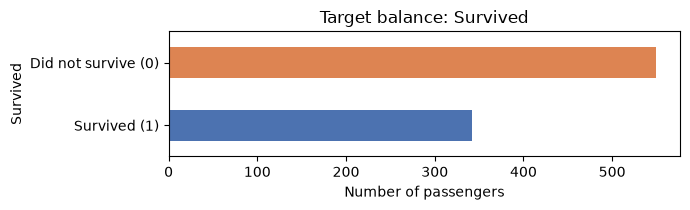

In [3]:
counts = df["Survived"].value_counts()
print(counts)
print()
print("Share of survivors:", round(counts[1] / len(df), 3))

# Horizontal bar chart of the class balance
labels = {0: "Did not survive (0)", 1: "Survived (1)"}
counts.rename(index=labels).sort_values().plot(kind="barh", color=["#4c72b0", "#dd8452"], figsize=(7, 2.2))
plt.xlabel("Number of passengers")
plt.title("Target balance: Survived")
plt.tight_layout()
plt.show()

About 38% survived and 62% did not. That is **imbalanced but not extreme** - both classes have hundreds of examples, so we can work with this directly.

### Which columns can be features?

Not every column is useful. Let's look at what we have, including how many values are missing per column. A **missing value** is an empty cell - the information was simply never recorded.

In [4]:
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(1),
    "example": df.iloc[0],
})
summary

,dtype,missing,missing_%,example
PassengerId,int64,0,0.0,1
Survived,int64,0,0.0,0
Pclass,int64,0,0.0,3
Name,str,0,0.0,"Braund, Mr. Owen Harris"
Sex,str,0,0.0,male
Age,float64,177,19.9,22.0
SibSp,int64,0,0.0,1
Parch,int64,0,0.0,0
Ticket,str,0,0.0,A/5 21171
Fare,float64,0,0.0,7.25


Here is our verdict, column by column:

| Column | Use as feature? | Why |
|---|---|---|
| `PassengerId` | No | Just a row number (an **identifier**). It carries no information about the person. |
| `Survived` | No - it is the target | This is the answer we want to predict, not an input. |
| `Pclass` | Yes | Ticket class (1st, 2nd, 3rd) - clearly related to wealth and cabin location. |
| `Name` | Not as-is | Free text; models cannot read sentences. But we will *mine* it for a `Title` feature in Section 7. |
| `Sex` | Yes | "Women and children first" - very likely predictive. |
| `Age` | Yes | Has ~20% missing values; we will fill them in Section 4. |
| `SibSp` | Yes | Number of siblings/spouses aboard. |
| `Parch` | Yes | Number of parents/children aboard. |
| `Ticket` | No | Messy identifier codes like "STON/O2. 3101282" - near-unique per passenger. |
| `Fare` | Yes | Ticket price - another wealth signal. |
| `Cabin` | No (for now) | 77% missing - too many gaps to fill honestly. (One exercise revisits it.) |
| `Embarked` | Yes | Port of boarding (C, Q, S); only 2 missing values. |

The general lesson: drop **identifiers** (unique per row), drop **free text** you cannot process yet, and be suspicious of columns that are **mostly missing**.

## 3. Split into train and test - FIRST

This is the most important habit in this entire notebook.

We split the data into two parts:

- **Training set** (80%): the examples the model learns from.
- **Test set** (20%): examples we lock away and only use at the very end, to check how the model performs on data it has never seen.

### Why split *before* preparing the data? Data leakage.

**Data leakage** is when information from the test set sneaks into the training process. Simple story: the test set is the final exam. If you *see the exam questions while studying*, your exam score looks great - but it says nothing about how well you would do on a truly new exam. Leakage makes a model look better than it really is, and you only find out when it fails in the real world.

Leakage is sneaky. Even something as innocent as "fill missing ages with the average age" leaks if that average was computed over *all* rows, because the test rows influenced the number. So: **split first, prepare after.**

We use `train_test_split` with two important settings:

- `random_state=42`: the shuffle is random, but this seed makes it the *same* random shuffle every time, so results are reproducible.
- `stratify=y`: keep the same survivor/non-survivor ratio in both parts. Without it, pure chance could give the test set an unusual mix.

In [5]:
from sklearn.model_selection import train_test_split

# X = the feature columns (we keep Name and others for now - Section 7 mines Name, and
# the final pipeline in Section 8 will pick exactly the columns it needs).
X = df.drop(columns=["Survived"])
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape[0], "rows")
print("Test set:    ", X_test.shape[0], "rows")

Training set: 712 rows
Test set:     179 rows


### Did stratify do its job?

Let's verify that the class balance survived the split. `value_counts(normalize=True)` shows shares instead of counts.

In [6]:
balance = pd.DataFrame({
    "full data": y.value_counts(normalize=True).round(3),
    "train": y_train.value_counts(normalize=True).round(3),
    "test": y_test.value_counts(normalize=True).round(3),
})
balance

,full data,train,test
Survived,,,
0,0.616,0.617,0.615
1,0.384,0.383,0.385


All three columns show (almost) identical shares. From this point on, the rule is simple:

- **Learn from `X_train` only** (compute medians, fit encoders, fit scalers, fit models).
- **Only apply** what was learned to `X_test`.

Watch the words `fit` and `transform` in the next sections - they encode exactly this rule.

## 4. Handling missing values the ML way

In Module 1 you may have filled gaps with `fillna`. In ML we use scikit-learn's **`SimpleImputer`**: an object that *learns* a filling value from data and can then apply it to any dataset.

- **Impute** = fill in a missing value with a reasonable substitute.
- For **numeric** columns we use the **median** (the middle value - robust against extreme outliers like a 512-pound fare).
- For **categorical** (text) columns we use the **most frequent** value.

The crucial pattern - the whole reason imputers are objects - is:

```text
imputer.fit(train)        -> LEARN the median from the TRAINING data only
imputer.transform(train)  -> APPLY it to the training data
imputer.transform(test)   -> APPLY the SAME value to the test data
```

We never call `fit` on the test set. The test set must be treated like the future: you cannot compute statistics on data you have not seen yet. Let's demonstrate this once, explicitly, on the `Age` column.

In [7]:
from sklearn.impute import SimpleImputer

print("Missing Age values - train:", X_train["Age"].isna().sum(), "| test:", X_test["Age"].isna().sum())

# 1) Create the imputer and let it LEARN from the training data only
age_imputer = SimpleImputer(strategy="median")
age_imputer.fit(X_train[["Age"]])          # note: fit on TRAIN only
print("Median age learned from the training set:", age_imputer.statistics_[0])

# 2) APPLY the learned median to both sets
age_train_filled = age_imputer.transform(X_train[["Age"]])
age_test_filled = age_imputer.transform(X_test[["Age"]])

print("Missing after imputing - train:", np.isnan(age_train_filled).sum(),
      "| test:", np.isnan(age_test_filled).sum())

Missing Age values - train: 137 | test: 40
Median age learned from the training set: 28.5
Missing after imputing - train: 0 | test: 0


Every gap is gone, and the test set was filled with the *training* median - zero leakage.

One more check: the median of the test set alone is usually slightly different. That difference is exactly the information we refuse to use.

In [8]:
print("Median Age computed on train:", X_train["Age"].median())
print("Median Age computed on test: ", X_test["Age"].median(), " <- we never use this one")

# The same idea works for text columns, with a different strategy:
embarked_imputer = SimpleImputer(strategy="most_frequent")
embarked_imputer.fit(X_train[["Embarked"]])
print("Most frequent port in the training set:", embarked_imputer.statistics_[0])

Median Age computed on train: 28.5
Median Age computed on test:  27.0  <- we never use this one
Most frequent port in the training set: S


## 5. Encoding categorical features

Models do math. You cannot multiply `"male"` by a number. So every text category must become numbers first. This conversion is called **encoding**.

### One-hot encoding: one column per category

The standard trick is **one-hot encoding**: give each category its own 0/1 column. Exactly one of those columns is "hot" (1) per row. Tiny hand-made example with the boarding port (`Embarked`):

| Passenger | Embarked | | Embarked_C | Embarked_Q | Embarked_S |
|---|---|---|---|---|---|
| Anna | C | -> | 1 | 0 | 0 |
| Ben | S | -> | 0 | 0 | 1 |
| Carla | Q | -> | 0 | 1 | 0 |
| David | S | -> | 0 | 0 | 1 |

Why not just C=1, Q=2, S=3? Because that would tell the model S is "three times" C, and that Q sits "between" C and S. Those orderings are meaningless for ports, and models *will* try to use them. One-hot columns carry no fake order.

Scikit-learn's **`OneHotEncoder`** follows the same fit/transform pattern as the imputer: it *learns* the list of categories from the training set, then applies it anywhere. Two settings matter:

- `handle_unknown="ignore"`: if the test set contains a category never seen in training, encode it as all zeros instead of crashing.
- `sparse_output=False`: return a normal, easy-to-read array. (In very old tutorials this parameter is called `sparse` - the modern name is `sparse_output`.)

In [9]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoder.fit(X_train[["Sex", "Pclass"]])          # LEARN the categories from train only

encoded_train = encoder.transform(X_train[["Sex", "Pclass"]])

# Show the result with readable column names
pd.DataFrame(encoded_train, columns=encoder.get_feature_names_out(), index=X_train.index).head()

,Sex_female,Sex_male,Pclass_1,Pclass_2,Pclass_3
692,0.0,1.0,0.0,0.0,1.0
481,0.0,1.0,0.0,1.0,0.0
527,0.0,1.0,1.0,0.0,0.0
855,1.0,0.0,0.0,0.0,1.0
801,1.0,0.0,0.0,1.0,0.0


Note that `Pclass` got one-hot encoded too, even though it is stored as a number. Ticket class is really a *category* (1st, 2nd, 3rd class), and treating it as three separate columns lets the model learn a different effect for each class.

### Why not `pd.get_dummies`?

Pandas has a one-liner, `pd.get_dummies`, that also one-hot encodes. It is fine for quick exploration, but it has a dangerous flaw for ML: it builds columns from *whatever categories happen to be in the data you give it*. Train and test can end up with **different columns**, and your model crashes (or worse, silently misreads columns). Watch:

In [10]:
train_tiny = pd.DataFrame({"Embarked": ["S", "C", "S", "C"]})   # no 'Q' passengers here
test_tiny = pd.DataFrame({"Embarked": ["Q", "S", "Q"]})          # 'Q' appears only here

print("get_dummies on train ->", list(pd.get_dummies(train_tiny).columns))
print("get_dummies on test  ->", list(pd.get_dummies(test_tiny).columns))
print()
print("Different columns! A model trained on the first cannot read the second.")
print()

# OneHotEncoder fitted on train handles this safely:
safe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
safe.fit(train_tiny)
print("OneHotEncoder columns (fixed by train):", list(safe.get_feature_names_out()))
print("Unseen 'Q' rows become all zeros:")
print(safe.transform(test_tiny))

get_dummies on train -> ['Embarked_C', 'Embarked_S']
get_dummies on test  -> ['Embarked_Q', 'Embarked_S']

Different columns! A model trained on the first cannot read the second.

OneHotEncoder columns (fixed by train): ['Embarked_C', 'Embarked_S']
Unseen 'Q' rows become all zeros:
[[0. 0.]
 [0. 1.]
 [0. 0.]]


This is why sklearn encoders win: **the training set fixes the columns once**, and every future dataset is forced into that exact shape.

### Ordinal encoding: only for truly ordered categories

Sometimes categories *do* have a real order: T-shirt sizes (S < M < L), education levels, satisfaction ratings. For those, **`OrdinalEncoder`** maps them to 0, 1, 2, ... *in an order you specify*, and the "greater than" relationship is real information the model can use.

In [11]:
from sklearn.preprocessing import OrdinalEncoder

shirts = pd.DataFrame({"size": ["S", "L", "M", "M", "S"]})

# We pass the order explicitly - never let it guess alphabetically ('L' < 'M' < 'S' would be wrong!)
size_encoder = OrdinalEncoder(categories=[["S", "M", "L"]])
shirts_encoded = size_encoder.fit_transform(shirts)

shirts_view = shirts.copy()
shirts_view["encoded"] = shirts_encoded
shirts_view

,size,encoded
0,S,0.0
1,L,2.0
2,M,1.0
3,M,1.0
4,S,0.0


Rule of thumb:

- Real order (sizes, ratings, levels) -> `OrdinalEncoder` with an explicit category order.
- No real order (ports, colors, sex, country) -> `OneHotEncoder`.
- When in doubt -> one-hot. A fake order hurts more than a few extra columns.

## 6. Feature scaling

Look at two of our numeric features: `Age` runs from 0 to 80, `Fare` from 0 to 512. Some models care a lot about that difference, others do not:

- **Distance-based / equation-based models** (k-nearest neighbors, logistic regression, neural networks) compare or combine features numerically. If `Fare` is numerically 6x bigger than `Age`, it silently dominates the result - not because it matters more, but because its numbers are bigger.
- **Rule-based models** (decision trees, random forests) only ask questions like "is Fare > 30?". Splitting at 30 works the same whether Fare goes to 512 or to 1. They do not care about scale.

Since we do not want our preprocessing to only work for one model family, we scale. **Scaling** means transforming a numeric column so all columns live on comparable ranges. The two classics:

| Scaler | What it does | Result |
|---|---|---|
| `StandardScaler` | subtract the mean, divide by the standard deviation | values centered on 0, mostly between -3 and +3 |
| `MinMaxScaler` | squeeze between the min and max | values between 0 and 1 |

Same golden rule as always: the scaler **learns the mean/min/max from the training set only**, then applies them to both sets. Let's see `Fare` before and after each scaler.

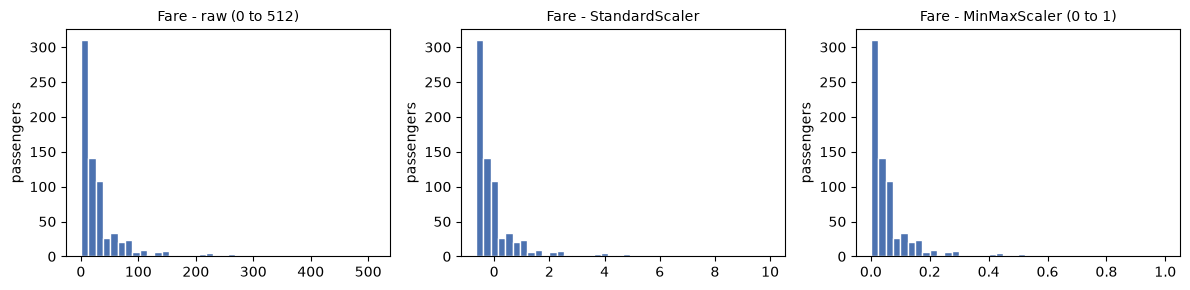

Raw fare:      min = 0.0  max = 512.3
StandardScaler: mean = -0.00  std = 1.00
MinMaxScaler:   min = 0.0  max = 1.0


In [12]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

std_scaler = StandardScaler().fit(X_train[["Fare"]])       # learn mean & std from TRAIN
mm_scaler = MinMaxScaler().fit(X_train[["Fare"]])          # learn min & max from TRAIN

fare_raw = X_train["Fare"]
fare_std = std_scaler.transform(X_train[["Fare"]]).ravel()
fare_mm = mm_scaler.transform(X_train[["Fare"]]).ravel()

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, values, title in [
    (axes[0], fare_raw, "Fare - raw (0 to 512)"),
    (axes[1], fare_std, "Fare - StandardScaler"),
    (axes[2], fare_mm, "Fare - MinMaxScaler (0 to 1)"),
]:
    ax.hist(values, bins=40, color="#4c72b0", edgecolor="white")
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("passengers")
plt.tight_layout()
plt.show()

print("Raw fare:      min = %.1f  max = %.1f" % (fare_raw.min(), fare_raw.max()))
print("StandardScaler: mean = %.2f  std = %.2f" % (fare_std.mean(), fare_std.std()))
print("MinMaxScaler:   min = %.1f  max = %.1f" % (fare_mm.min(), fare_mm.max()))

Important observation: **the shape of the histogram did not change** - only the numbers on the x-axis did. Scaling does not destroy information; it just re-labels the ruler. In this module we use `StandardScaler`, which is the safe default for most models.

## 7. Feature engineering - creating better inputs

**Feature engineering** is creating new, more informative columns from the ones you already have. It is where humans still beat machines: the model only sees numbers, but *you* know that "Braund, Mr. Owen Harris" contains a social title, and that siblings + parents = family size. Good features often improve a model more than a fancier algorithm does.

We will build the three engineered features this whole module uses:

1. `Title` - extracted from `Name` (Mr / Mrs / Miss / Master / Rare)
2. `FamilySize` - how many family members traveled together
3. `IsAlone` - was the passenger traveling alone?

### 7.1 Extracting `Title` from `Name`

Every name follows the pattern `Lastname, Title. Firstname`. We can pull out the title with `.str.extract` and a **regular expression (regex)** - a mini-language for describing text patterns. Our pattern is `" ([A-Za-z]+)\."`. Character by character:

| Piece | Meaning |
|---|---|
| `" "` (space) | match a literal space |
| `(` ... `)` | capture (keep) whatever matches inside the parentheses |
| `[A-Za-z]` | any single letter, uppercase or lowercase |
| `+` | one or more of the previous thing (so: one or more letters) |
| `\.` | a literal period. The backslash says "a real dot", because a bare `.` means "any character" in regex |

In words: *"find a space, then capture a run of letters, that is immediately followed by a period"*. In a name like `Braund, Mr. Owen Harris`, the only place that matches is ` Mr.` - and the captured part is `Mr`.

In [13]:
raw_titles = X_train["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
# expand=False -> give us a single column (a Series), not a table

print("A few names and what we extracted:")
preview = pd.DataFrame({"Name": X_train["Name"], "extracted Title": raw_titles})
print(preview.head(5).to_string(index=False))
print()
print("All titles found in the training set:")
print(raw_titles.value_counts())

A few names and what we extracted:
                                       Name extracted Title
                               Lam, Mr. Ali              Mr
           Frost, Mr. Anthony Wood "Archie"              Mr
                         Farthing, Mr. John              Mr
                 Aks, Mrs. Sam (Leah Rosen)             Mrs
Collyer, Mrs. Harvey (Charlotte Annie Tate)             Mrs

All titles found in the training set:
Name
Mr          412
Miss        141
Mrs         107
Master       31
Dr            6
Rev           5
Col           2
Mlle          2
Major         1
Lady          1
Sir           1
Ms            1
Jonkheer      1
Don           1
Name: count, dtype: int64


### The same extraction with a plain for-loop

Regex can feel like magic, so let's do the same job with the string tools you know from Module 1: a `for` loop, `split`, and `strip`. The recipe: take the text after the comma, then take the text before the first period, then trim spaces.

(We loop over the *full* dataset here purely to compare the two methods on every name. Nothing is being learned or fitted, so there is no leakage risk in a row-by-row text operation.)

In [14]:
titles_loop = []
for name in df["Name"]:                      # e.g. "Braund, Mr. Owen Harris"
    after_comma = name.split(",")[1]         # -> " Mr. Owen Harris"
    before_period = after_comma.split(".")[0]  # -> " Mr"
    titles_loop.append(before_period.strip())  # -> "Mr"

titles_regex_full = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
titles_loop = pd.Series(titles_loop, index=df.index)

disagreements = df.loc[titles_loop != titles_regex_full, "Name"]
print("Names where the loop and the regex disagree:", len(disagreements))
for name in disagreements:
    print(" -", name)

Names where the loop and the regex disagree: 1
 - Rothes, the Countess. of (Lucy Noel Martha Dyer-Edwards)


The two methods agree on essentially every name - the regex is just one line instead of five. (If you see a disagreement above, it is an unusual aristocratic name like *"the Countess."*, where the regex's stricter pattern - letters directly before the period - does a better job.) That is why regex is worth learning: same loop logic, compressed into a pattern.

### 7.2 Grouping rare titles

The training set has a handful of common titles and a long tail of rare ones (Dr, Rev, Col, Countess, ...) with only a few passengers each. A model cannot learn anything reliable from 2 examples of "Major", so we group all rare titles into one bucket called `"Rare"`, and merge French variants into their English equivalents (`Mlle` = Mademoiselle = Miss, `Mme` = Madame = Mrs).

We do this with a **mapping dictionary**: every known title maps to one of five groups, and `.map` applies it. Titles that are not in the dictionary become `NaN`, and `.fillna("Rare")` sweeps them all into the Rare bucket.

In [15]:
title_map = {
    "Mr": "Mr", "Mrs": "Mrs", "Miss": "Miss", "Master": "Master",   # keep the big four
    "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",                     # merge French/modern variants
}
# Everything else (Dr, Rev, Col, Major, Countess, ...) is not in the dict -> becomes "Rare"

titles_grouped = raw_titles.map(title_map).fillna("Rare")
print(titles_grouped.value_counts())

Name
Mr        412
Miss      144
Mrs       107
Master     31
Rare       18
Name: count, dtype: int64


Five clean groups, each with enough passengers to learn from. (`Master` was the old-fashioned title for young boys - so it secretly encodes "male child", which matters a lot on a sinking ship.)

### 7.3 `FamilySize` and `IsAlone`

`SibSp` (siblings + spouse) and `Parch` (parents + children) both describe family, but each tells only half the story. Adding them - plus 1 for the passenger themselves - gives the size of the whole traveling group. And from that we get a simple yes/no feature: was this person alone?

In [16]:
family_size = X_train["SibSp"] + X_train["Parch"] + 1
is_alone = (family_size == 1).astype(int)     # True/False -> 1/0

print("FamilySize distribution in the training set:")
print(family_size.value_counts().sort_index())
print()
print("Passengers traveling alone:", is_alone.sum(), "of", len(is_alone))

FamilySize distribution in the training set:
1     434
2     129
3      77
4      22
5      14
6      16
7      11
8       4
11      5
Name: count, dtype: int64

Passengers traveling alone: 434 of 712


### 7.4 Binning: turning a number into categories

The opposite move also exists: turning a continuous number into a few categories. This is called **discretization** (or **binning**). For example, exact age may matter less than *life stage* - a 4-year-old and a 9-year-old are both "children" as far as lifeboats are concerned. `pd.cut` chops a numeric column into labeled ranges:

In [17]:
age_group = pd.cut(
    X_train["Age"],
    bins=[0, 12, 19, 35, 60, 120],
    labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"],
)
print(age_group.value_counts())
print()
print("Note: passengers with missing Age get a missing AgeGroup too:", age_group.isna().sum(), "missing")

Age
YoungAdult    263
Adult         167
Teen           74
Child          55
Senior         16
Name: count, dtype: int64

Note: passengers with missing Age get a missing AgeGroup too: 137 missing


Binning is a useful tool to know, but we will not put `AgeGroup` in our canonical feature set (one of the exercises does). Now, the moment of truth for our engineered features.

### 7.5 Do the new features carry signal?

A new feature is only worth keeping if it actually relates to the target. Quick check: group the training data by each new feature and compute the average of `Survived` (since Survived is 0 or 1, the average is exactly the **survival rate**).

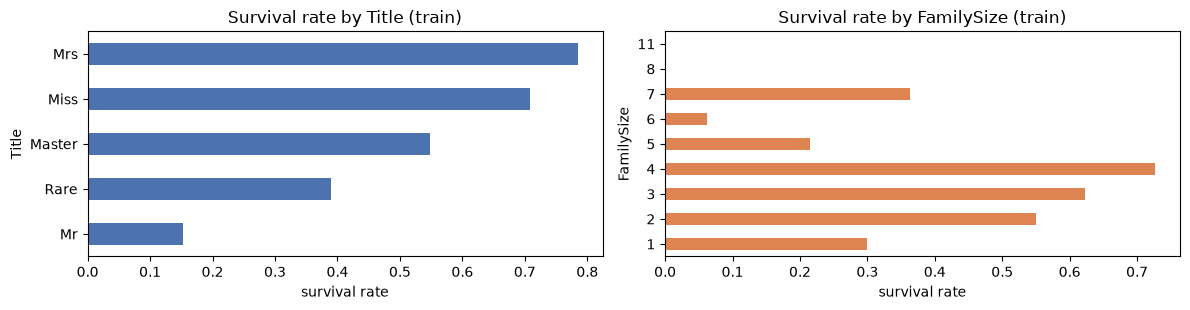

In [18]:
check = X_train.copy()
check["Title"] = titles_grouped
check["FamilySize"] = family_size
check["Survived"] = y_train        # indexes align, so this pairs rows correctly

fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))

check.groupby("Title")["Survived"].mean().sort_values().plot(
    kind="barh", ax=axes[0], color="#4c72b0")
axes[0].set_title("Survival rate by Title (train)")
axes[0].set_xlabel("survival rate")

check.groupby("FamilySize")["Survived"].mean().plot(
    kind="barh", ax=axes[1], color="#dd8452")
axes[1].set_title("Survival rate by FamilySize (train)")
axes[1].set_xlabel("survival rate")

plt.tight_layout()
plt.show()

Strong signal in both:

- `Title` separates the data dramatically: "Mrs" and "Miss" survived far more often than "Mr" - and "Master" (young boys) much more than adult men. Title compresses sex, age, and social status into one feature.
- `FamilySize` shows a pattern a single column could not: solo travelers and very large families both fared badly; small families (2-4) did best.

### 7.6 Package it into a function

We need these features on the training set, the test set, and any future data. Any time you say "and also on...", write a function. Note this function works **row by row** - it learns nothing from the dataset as a whole - so applying it before or after the split changes nothing and leaks nothing.

In [19]:
def add_engineered_features(data):
    """Return a copy of the dataframe with Title, FamilySize and IsAlone added."""
    data = data.copy()
    raw = data["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
    data["Title"] = raw.map(title_map).fillna("Rare")
    data["FamilySize"] = data["SibSp"] + data["Parch"] + 1
    data["IsAlone"] = (data["FamilySize"] == 1).astype(int)
    return data

X_train_fe = add_engineered_features(X_train)
X_test_fe = add_engineered_features(X_test)

X_train_fe[["Name", "Title", "SibSp", "Parch", "FamilySize", "IsAlone"]].head()

,Name,Title,SibSp,Parch,FamilySize,IsAlone
692,"Lam, Mr. Ali",Mr,0,0,1,1
481,"Frost, Mr. Anthony Wood ""Archie""",Mr,0,0,1,1
527,"Farthing, Mr. John",Mr,0,0,1,1
855,"Aks, Mrs. Sam (Leah Rosen)",Mrs,0,1,2,0
801,"Collyer, Mrs. Harvey (Charlotte Annie Tate)",Mrs,1,1,3,0


## 8. Putting it all together: Pipelines

So far we have applied each preparation step by hand: fit the imputer, transform, fit the encoder, transform, fit the scaler, transform... on train, then again on test. That is a lot of places to make a mistake - forget one `transform`, or accidentally `fit` on test, and everything downstream is silently wrong.

Scikit-learn solves this with two building blocks:

- **`Pipeline`**: a chain of steps that run in order. Calling `fit` fits every step on the data flowing through; calling `transform` applies every step. One object, no forgotten steps.
- **`ColumnTransformer`**: sends different columns down different pipelines - numbers to the numeric pipeline, text to the categorical pipeline - and glues the results side by side.

Three reasons pipelines are non-negotiable in practice:

1. **No leakage**: `fit` only ever touches what you pass it. Fit on train, transform on test - guaranteed.
2. **No forgotten steps**: preparation is one object, applied identically every time.
3. **Portability**: the same object handles new data next week. (And in notebook 3 of this module you will see that a pipeline can be saved to a file and deployed.)

Now we build the **canonical preprocessing for this whole module** - notebooks 2 and 3 reuse exactly this setup:

- numeric features `["Age", "Fare", "SibSp", "Parch", "FamilySize"]` -> median imputer, then standard scaler
- categorical features `["Pclass", "Sex", "Embarked", "Title"]` -> most-frequent imputer, then one-hot encoder

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

numeric_features = ["Age", "Fare", "SibSp", "Parch", "FamilySize"]
categorical_features = ["Pclass", "Sex", "Embarked", "Title"]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])
# Columns not listed (Name, Ticket, Cabin, PassengerId, IsAlone...) are dropped automatically.

preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

Now the payoff. Watch the verbs carefully:

- `fit_transform(X_train_fe)` = learn all medians / categories / means from the **training** set, and transform it.
- `transform(X_test_fe)` = apply those same learned values to the **test** set. No fitting.

In [21]:
X_train_ready = preprocess.fit_transform(X_train_fe)   # LEARN from train + transform train
X_test_ready = preprocess.transform(X_test_fe)          # only APPLY to test

feature_names = preprocess.get_feature_names_out()
print("Final feature matrix - train:", X_train_ready.shape, "| test:", X_test_ready.shape)
print()
print("The", len(feature_names), "final features:")
for name in feature_names:
    print(" -", name)

Final feature matrix - train: (712, 18) | test: (179, 18)

The 18 final features:
 - num__Age
 - num__Fare
 - num__SibSp
 - num__Parch
 - num__FamilySize
 - cat__Pclass_1
 - cat__Pclass_2
 - cat__Pclass_3
 - cat__Sex_female
 - cat__Sex_male
 - cat__Embarked_C
 - cat__Embarked_Q
 - cat__Embarked_S
 - cat__Title_Master
 - cat__Title_Miss
 - cat__Title_Mr
 - cat__Title_Mrs
 - cat__Title_Rare


Our 4 categorical columns fanned out into one-hot columns, and together with the 5 scaled numeric columns we get the final model-ready matrix. Every value is a number, there are no gaps, and everything is on a sensible scale. Here is what the model will actually see:

In [22]:
pd.DataFrame(X_train_ready, columns=feature_names, index=X_train_fe.index).head().round(2)

,num__Age,num__Fare,num__SibSp,num__Parch,num__FamilySize,cat__Pclass_1,cat__Pclass_2,cat__Pclass_3,cat__Sex_female,cat__Sex_male,cat__Embarked_C,cat__Embarked_Q,cat__Embarked_S,cat__Title_Master,cat__Title_Miss,cat__Title_Mr,cat__Title_Mrs,cat__Title_Rare
692,-0.08,0.51,-0.47,-0.47,-0.56,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
481,-0.08,-0.66,-0.47,-0.47,-0.56,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
527,-0.08,3.96,-0.47,-0.47,-0.56,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
855,-0.89,-0.47,-0.47,0.73,0.07,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
801,0.11,-0.12,0.48,0.73,0.70,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


## 9. Sanity checkpoint: does it actually work?

One last step: prove the prepared data can feed a real model. We chain our preprocessing and a **logistic regression** (a simple, classic classification model - notebook 2 explains it properly) into a single pipeline and check the accuracy.

**This is just a smoke test.** Choosing the right model, evaluating it honestly, and tuning it is the whole next notebook.

In [23]:
from sklearn.linear_model import LogisticRegression

model = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=1000, random_state=42)),
])
model.fit(X_train_fe, y_train)

print("Train accuracy:", round(model.score(X_train_fe, y_train), 3))
print("Test accuracy: ", round(model.score(X_test_fe, y_test), 3))

Train accuracy: 0.829
Test accuracy:  0.838


About 84% accuracy on unseen passengers - a long way from the 62% a "predict nobody survives" model would get. Our prepared data works. Notice the best part: because preprocessing lives *inside* the model pipeline, we fed it the raw-ish dataframes and never had to think about imputing/encoding/scaling again.

## 10. Key takeaways

The golden rules (worth memorizing):

- **Split first.** Create train and test sets before any preparation. The test set is the final exam - lock it away.
- **Fit on train only.** Every imputer, encoder, and scaler *learns* from the training set and is merely *applied* to the test set. `fit` on train, `transform` on both.
- **Pipelines always.** Wire preprocessing and model into one `Pipeline` + `ColumnTransformer`. It makes leakage nearly impossible and forgotten steps actually impossible.

And the toolbox:

- Drop identifiers, free text you cannot process, and mostly-missing columns.
- Missing values: `SimpleImputer` - median for numbers, most frequent for categories.
- Categories to numbers: `OneHotEncoder(handle_unknown="ignore")` for unordered categories; `OrdinalEncoder` only when a real order exists. Avoid `pd.get_dummies` for ML - it can produce mismatched train/test columns.
- Scaling: `StandardScaler` is the safe default; distance/equation-based models need it, trees do not care.
- Feature engineering is where you add human knowledge: `Title` from names, `FamilySize` from two half-features, `IsAlone`, binning with `pd.cut`. Always verify new features carry signal (group by the feature, look at the target rate).

## 11. Practice exercises

Try these yourself before peeking at the solutions. All of them use the variables already in memory (`df`, `X_train_fe`, `X_test_fe`, `y_train`, `y_test`, `preprocess`...).

**Exercise 1 - A `Deck` feature from `Cabin`.** The `Cabin` column is 77% missing, but the first letter of a cabin code (e.g. `C85` -> `C`) is the deck of the ship, and decks were at different heights. Create a `Deck` feature on the *training* set: first letter of `Cabin`, with missing cabins becoming `"U"` (unknown). Then compute the survival rate per deck and plot it as a horizontal bar chart. Does deck carry signal?

**Exercise 2 - `FarePerPerson`.** `Fare` is often the price of the *whole group's* ticket. Add a `FarePerPerson` column (`Fare / FamilySize`) to the training set, and compare the median `Fare` and median `FarePerPerson` per passenger class (`Pclass`). What changes?

**Exercise 3 - A different imputation strategy.** Rebuild the numeric pipeline using `SimpleImputer(strategy="mean")` instead of `"median"`, rebuild the ColumnTransformer and the logistic-regression pipeline, and compare the test accuracy with the Section 9 result. Does the choice matter much here? Print the mean and the median of `Age` in the training set to see how different the two filling values actually are.

**Exercise 4 - Add `AgeGroup` as a categorical feature.** Use `pd.cut` (as in Section 7.4) to add an `AgeGroup` column to both `X_train_fe` and `X_test_fe`. Then build a new ColumnTransformer where `AgeGroup` is one of the categorical features, fit the logistic-regression pipeline again, and compare the test accuracy. Hint: `pd.cut` produces a special categorical dtype - convert it with `.astype(str)` so the imputer and encoder treat it as ordinary text (missing ages become the string `"nan"`, which the encoder simply treats as one more category).

## 12. Solutions

### Solution 1 - Deck from Cabin

Deck
U    552
C     41
B     34
E     29
D     26
A     14
F     11
G      4
T      1
Name: count, dtype: int64


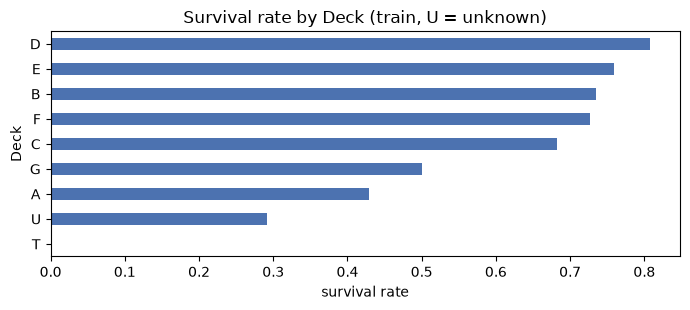

In [24]:
# First letter of the cabin code; missing cabins become "U" (unknown)
sol1 = X_train_fe.copy()
sol1["Deck"] = sol1["Cabin"].str[0].fillna("U")
sol1["Survived"] = y_train

print(sol1["Deck"].value_counts())

deck_rate = sol1.groupby("Deck")["Survived"].mean().sort_values()
deck_rate.plot(kind="barh", color="#4c72b0", figsize=(7, 3.2))
plt.xlabel("survival rate")
plt.title("Survival rate by Deck (train, U = unknown)")
plt.tight_layout()
plt.show()

There is signal: passengers with a *known* cabin (mostly 1st class) survived far more often than the "U" group. Careful with the small decks though - some have only a handful of passengers, so their rates are noisy.

### Solution 2 - FarePerPerson

In [25]:
sol2 = X_train_fe.copy()
sol2["FarePerPerson"] = sol2["Fare"] / sol2["FamilySize"]

comparison = sol2.groupby("Pclass")[["Fare", "FarePerPerson"]].median().round(2)
print(comparison)

         Fare  FarePerPerson
Pclass                      
1       57.98          35.50
2       14.50          13.00
3        8.05           7.75


The gap between classes shrinks once we divide by group size: part of the huge 1st-class fares was simply *larger groups on one ticket*. `FarePerPerson` is a cleaner wealth signal than raw `Fare`.

### Solution 3 - Mean vs median imputation

In [26]:
print("Age in train -> mean: %.2f | median: %.2f" % (X_train_fe["Age"].mean(), X_train_fe["Age"].median()))

numeric_pipeline_mean = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
])
preprocess_mean = ColumnTransformer(transformers=[
    ("num", numeric_pipeline_mean, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])
model_mean = Pipeline(steps=[
    ("prep", preprocess_mean),
    ("clf", LogisticRegression(max_iter=1000, random_state=42)),
])
model_mean.fit(X_train_fe, y_train)

print("Test accuracy with MEDIAN imputation:", round(model.score(X_test_fe, y_test), 3))
print("Test accuracy with MEAN imputation:  ", round(model_mean.score(X_test_fe, y_test), 3))

Age in train -> mean: 29.81 | median: 28.50
Test accuracy with MEDIAN imputation: 0.838
Test accuracy with MEAN imputation:   0.844


Mean (about 29.8) and median (28.5) are close here, so the accuracies are nearly identical. The choice matters more when a column has extreme outliers - like `Fare`, where a few 500+ tickets drag the mean up while the median stays put. Median is the safer habit.

### Solution 4 - AgeGroup as an extra categorical feature

In [27]:
def add_age_group(data):
    data = data.copy()
    data["AgeGroup"] = pd.cut(
        data["Age"],
        bins=[0, 12, 19, 35, 60, 120],
        labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"],
    ).astype(str)          # plain strings; missing Age becomes the string "nan"
    return data

X_train_ag = add_age_group(X_train_fe)
X_test_ag = add_age_group(X_test_fe)

preprocess_ag = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features + ["AgeGroup"]),
])
model_ag = Pipeline(steps=[
    ("prep", preprocess_ag),
    ("clf", LogisticRegression(max_iter=1000, random_state=42)),
])
model_ag.fit(X_train_ag, y_train)

print("Test accuracy without AgeGroup:", round(model.score(X_test_fe, y_test), 3))
print("Test accuracy with AgeGroup:   ", round(model_ag.score(X_test_ag, y_test), 3))

Test accuracy without AgeGroup: 0.838
Test accuracy with AgeGroup:    0.844


The change is small: `Age` (scaled) and `Title` already capture most of the age story, so `AgeGroup` adds little *new* information. That is a common and important lesson - more features is not automatically better. In the next notebook we make such comparisons properly, with cross-validation instead of a single test score.

**Next up: notebook 2 - training, evaluating, and comparing classification models on exactly this prepared data.**